# MATH 5010 Computer Lab — Section 2
## Random Variables and Distribution Families

**Full-solution version**

This lab supports Section 2 of MATH 5010. The goal is to use Python to make the core ideas of random variables and probability distributions concrete.

Section 2 themes covered here:

1. Random variables as functions from outcomes to numbers.
2. CDF, PMF, and PDF.
3. Discrete and continuous distributions.
4. Common distribution families: Bernoulli, Binomial, Geometric, Poisson, Discrete Uniform, Hypergeometric, Negative Binomial, Uniform, Exponential, Gamma, Normal, Beta, Lognormal, Laplace, and Logistic.
5. Exponential-family form and the meaning of natural parameters and log-partition functions.
6. Location-scale families.

Throughout the notebook, each exercise is followed by a complete solution.

## 0. Python setup

We will use `numpy` for simulation, `scipy.stats` for probability distributions, and `matplotlib` for plots.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import comb, factorial, gamma, beta as beta_func

rng = np.random.default_rng(5010)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

print("Setup complete.")

Setup complete.


## 1. Random variables as functions

A random variable is a function from a sample space to real numbers. For example, if two dice are rolled, one possible random variable is

$$
X = \text{sum of the two dice}.
$$

The sample space consists of 36 equally likely ordered pairs.

In [2]:
# Sample space for two dice
outcomes = [(i, j) for i in range(1, 7) for j in range(1, 7)]

def X_sum(outcome):
    i, j = outcome
    return i + j

values = np.array([X_sum(s) for s in outcomes])

pmf_sum = pd.Series(values).value_counts(normalize=True).sort_index()
cdf_sum = pmf_sum.cumsum()

summary_sum = pd.DataFrame({
    "x": pmf_sum.index,
    "P(X=x)": pmf_sum.values,
    "F(x)=P(X<=x)": cdf_sum.values
})
summary_sum

,x,P(X=x),F(x)=P(X<=x)
0,2,0.027778,0.027778
1,3,0.055556,0.083333
2,4,0.083333,0.166667
3,5,0.111111,0.277778
4,6,0.138889,0.416667
5,7,0.166667,0.583333
6,8,0.138889,0.722222
7,9,0.111111,0.833333
8,10,0.083333,0.916667
9,11,0.055556,0.972222


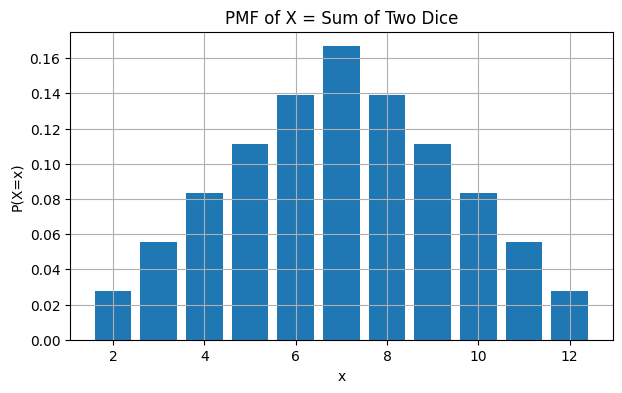

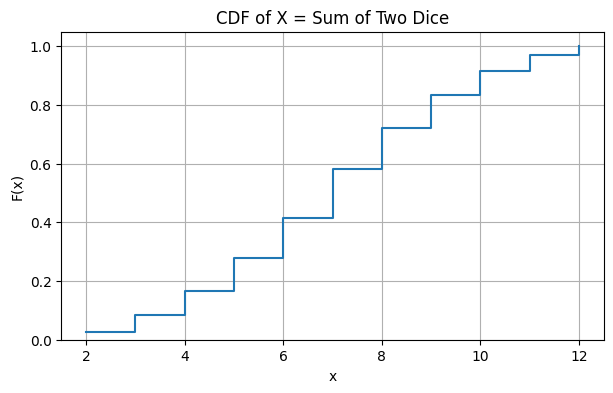

In [3]:
# Plot PMF and CDF
plt.figure()
plt.bar(pmf_sum.index, pmf_sum.values)
plt.xlabel("x")
plt.ylabel("P(X=x)")
plt.title("PMF of X = Sum of Two Dice")
plt.show()

plt.figure()
plt.step(cdf_sum.index, cdf_sum.values, where="post")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("CDF of X = Sum of Two Dice")
plt.ylim(0, 1.05)
plt.show()

### Exercise 1.1

For $X=$ sum of two dice, compute

$$
P(5 \le X \le 9), \qquad P(X>9), \qquad F(7).
$$

### Solution

We can compute these probabilities by summing the PMF or using the CDF.

In [4]:
prob_5_to_9 = pmf_sum.loc[5:9].sum()
prob_gt_9 = pmf_sum.loc[pmf_sum.index > 9].sum()
F_7 = cdf_sum.loc[7]

print(f"P(5 <= X <= 9) = {prob_5_to_9:.4f} = {prob_5_to_9.as_integer_ratio()[0]}/{prob_5_to_9.as_integer_ratio()[1]}")
print(f"P(X > 9)       = {prob_gt_9:.4f}")
print(f"F(7)           = {F_7:.4f}")

P(5 <= X <= 9) = 0.6667 = 3002399751580331/4503599627370496
P(X > 9)       = 0.1667
F(7)           = 0.5833


## 2. CDF, PMF, and PDF

For any random variable $X$, the cumulative distribution function is

$$
F_X(x)=P(X\le x).
$$

For a discrete random variable, the PMF is

$$
p_X(x)=P(X=x).
$$

For a continuous random variable, the PDF $f_X(x)$ satisfies

$$
P(a\le X\le b)=\int_a^b f_X(x)\,dx.
$$

### Exercise 2.1: A continuous distribution from a CDF

Suppose a random variable $Y$ has CDF

$$
F_Y(y)=1-\frac{1}{y^2}, \qquad y\ge 1,
$$

and $F_Y(y)=0$ for $y<1$.

1. Verify numerically that this behaves like a CDF.
2. Find the PDF $f_Y(y)$.
3. Approximate $P(1.5<Y<3)$ using the CDF and numerical integration.

### Solution

The derivative is

$$
f_Y(y)=F_Y'(y)=\frac{2}{y^3}, \qquad y\ge 1.
$$

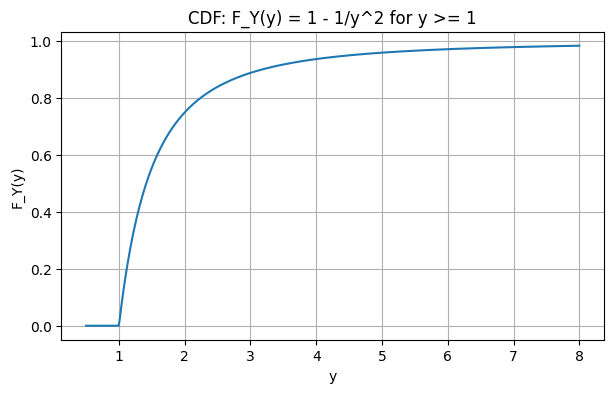

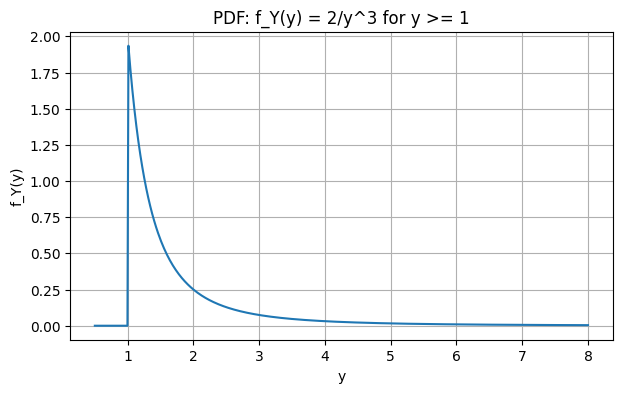

P(1.5 < Y < 3) by CDF        = 0.333333
P(1.5 < Y < 3) by integration = 0.333333


/tmp/ipykernel_17716/3622723019.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  prob_integral = np.trapz(f_Y(grid), grid)


In [5]:
def F_Y(y):
    y = np.asarray(y)
    return np.where(y < 1, 0.0, 1 - 1 / y**2)

def f_Y(y):
    y = np.asarray(y)
    return np.where(y < 1, 0.0, 2 / y**3)

ys = np.linspace(0.5, 8, 500)

plt.figure()
plt.plot(ys, F_Y(ys))
plt.xlabel("y")
plt.ylabel("F_Y(y)")
plt.title("CDF: F_Y(y) = 1 - 1/y^2 for y >= 1")
plt.show()

plt.figure()
plt.plot(ys, f_Y(ys))
plt.xlabel("y")
plt.ylabel("f_Y(y)")
plt.title("PDF: f_Y(y) = 2/y^3 for y >= 1")
plt.show()

# CDF method
prob_cdf = F_Y(3) - F_Y(1.5)

# numerical integration method
grid = np.linspace(1.5, 3, 100_000)
prob_integral = np.trapz(f_Y(grid), grid)

print(f"P(1.5 < Y < 3) by CDF        = {prob_cdf:.6f}")
print(f"P(1.5 < Y < 3) by integration = {prob_integral:.6f}")

## 3. Common discrete distributions

We now compute, visualize, and simulate several discrete distributions.

### 3.1 Bernoulli and Binomial distributions

A Bernoulli random variable records success/failure:

$$
X\sim \operatorname{Bernoulli}(p),\qquad P(X=1)=p,\quad P(X=0)=1-p.
$$

A Binomial random variable counts the number of successes in $n$ independent Bernoulli trials:

$$
Y\sim \operatorname{Binomial}(n,p),\qquad P(Y=k)=\binom{n}{k}p^k(1-p)^{n-k}.
$$

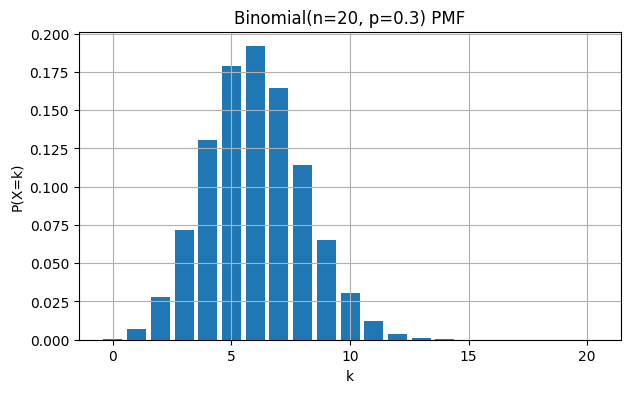

Theoretical mean = np = 6.000
Theoretical variance = np(1-p) = 4.200


In [6]:
n, p = 20, 0.30
k = np.arange(n + 1)
pmf_binom = stats.binom.pmf(k, n, p)

plt.figure()
plt.bar(k, pmf_binom)
plt.xlabel("k")
plt.ylabel("P(X=k)")
plt.title(f"Binomial(n={n}, p={p}) PMF")
plt.show()

print(f"Theoretical mean = np = {n*p:.3f}")
print(f"Theoretical variance = np(1-p) = {n*p*(1-p):.3f}")

### Exercise 3.1

Let $X\sim \operatorname{Binomial}(20,0.3)$. Compute

$$
P(X\ge 8),\qquad P(4\le X\le 10),
$$

and verify them by simulation.

### Solution

In [7]:
prob_ge_8 = 1 - stats.binom.cdf(7, n, p)
prob_4_to_10 = stats.binom.cdf(10, n, p) - stats.binom.cdf(3, n, p)

sim = rng.binomial(n, p, size=200_000)
sim_ge_8 = np.mean(sim >= 8)
sim_4_to_10 = np.mean((sim >= 4) & (sim <= 10))

print("Exact probabilities:")
print(f"P(X >= 8)      = {prob_ge_8:.5f}")
print(f"P(4 <= X <= 10)= {prob_4_to_10:.5f}")
print("\nSimulation estimates:")
print(f"P(X >= 8)      ≈ {sim_ge_8:.5f}")
print(f"P(4 <= X <= 10)≈ {sim_4_to_10:.5f}")

Exact probabilities:
P(X >= 8)      = 0.22773
P(4 <= X <= 10)= 0.87577

Simulation estimates:
P(X >= 8)      ≈ 0.22822
P(4 <= X <= 10)≈ 0.87579


### 3.2 Geometric distribution

A geometric random variable counts the number of trials until the first success:

$$
P(X=k)=(1-p)^{k-1}p,\qquad k=1,2,3,\ldots
$$

It has mean $1/p$ and variance $(1-p)/p^2$.

### Exercise 3.2

A test independently passes with probability $p=0.9$. Let $T$ be the number of tests required until the first pass.

1. Find $P(T>3)$.
2. Find the smallest $m$ such that $P(T\le m)\ge 0.99$.

### Solution

Since $T\sim \operatorname{Geometric}(0.9)$,

$$
P(T>3)=(1-p)^3=(0.1)^3=0.001.
$$

In [8]:
p_pass = 0.9
prob_T_gt_3 = (1 - p_pass)**3

m_values = np.arange(1, 20)
cdf_values = stats.geom.cdf(m_values, p_pass)
m_min = m_values[np.where(cdf_values >= 0.99)[0][0]]

print(f"P(T > 3) = {prob_T_gt_3:.6f}")
print(f"Smallest m with P(T <= m) >= 0.99 is m = {m_min}")
print(f"P(T <= {m_min}) = {stats.geom.cdf(m_min, p_pass):.6f}")

P(T > 3) = 0.001000
Smallest m with P(T <= m) >= 0.99 is m = 2
P(T <= 2) = 0.990000


### 3.3 Poisson distribution

A Poisson random variable models the number of arrivals in a fixed time interval when events occur at rate $\lambda$:

$$
P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!},\qquad k=0,1,2,\ldots
$$

It has mean $\lambda$ and variance $\lambda$.

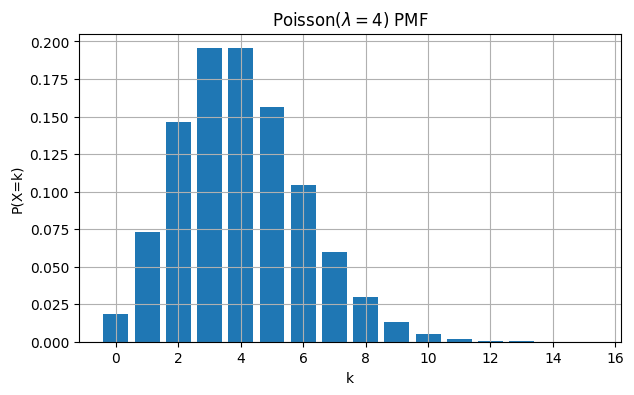

Mean = 4.0, variance = 4.0
P(X >= 7) = 0.11067


In [9]:
lam = 4.0
k = np.arange(0, 16)
pmf_pois = stats.poisson.pmf(k, lam)

plt.figure()
plt.bar(k, pmf_pois)
plt.xlabel("k")
plt.ylabel("P(X=k)")
plt.title(r"Poisson($\lambda=4$) PMF")
plt.show()

print(f"Mean = {lam}, variance = {lam}")
print(f"P(X >= 7) = {1 - stats.poisson.cdf(6, lam):.5f}")

### Exercise 3.3: Poisson approximation to Binomial

When $n$ is large and $p$ is small with $np\approx \lambda$, we have approximately

$$
\operatorname{Binomial}(n,p)\approx \operatorname{Poisson}(\lambda).
$$

Compare $\operatorname{Binomial}(100,0.04)$ with $\operatorname{Poisson}(4)$.

### Solution

In [10]:
n_big, p_small = 100, 0.04
lam_approx = n_big * p_small
k = np.arange(0, 16)

binom_probs = stats.binom.pmf(k, n_big, p_small)
pois_probs = stats.poisson.pmf(k, lam_approx)

comparison = pd.DataFrame({
    "k": k,
    "Binomial(100,0.04)": binom_probs,
    "Poisson(4)": pois_probs,
    "absolute difference": np.abs(binom_probs - pois_probs)
})
comparison

,k,"Binomial(100,0.04)",Poisson(4),absolute difference
0,0,0.016870,0.018316,0.001445
1,1,0.070293,0.073263,0.002970
2,2,0.144979,0.146525,0.001546
3,3,0.197333,0.195367,0.001966
4,4,0.199388,0.195367,0.004022
5,5,0.159511,0.156293,0.003217
6,6,0.105233,0.104196,0.001037
7,7,0.058880,0.059540,0.000660
8,8,0.028520,0.029770,0.001250
9,9,0.012147,0.013231,0.001084


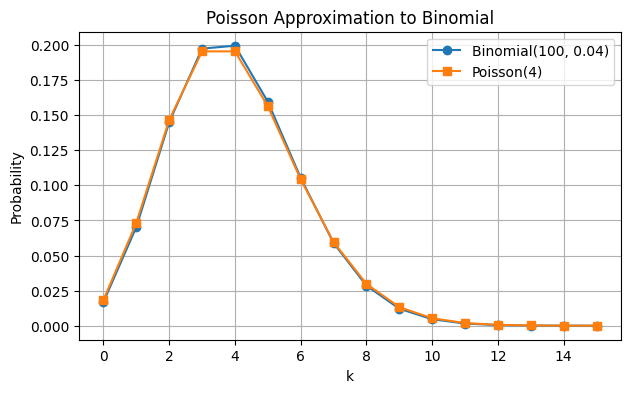

In [11]:
plt.figure()
plt.plot(k, binom_probs, marker="o", label="Binomial(100, 0.04)")
plt.plot(k, pois_probs, marker="s", label="Poisson(4)")
plt.xlabel("k")
plt.ylabel("Probability")
plt.title("Poisson Approximation to Binomial")
plt.legend()
plt.show()

### 3.4 Discrete uniform distribution

A discrete uniform distribution assigns equal probability to finitely many integer values. If

$$
X\sim \operatorname{DiscreteUniform}\{a,a+1,\ldots,b\},
$$

then

$$
P(X=x)=\frac{1}{b-a+1}.
$$

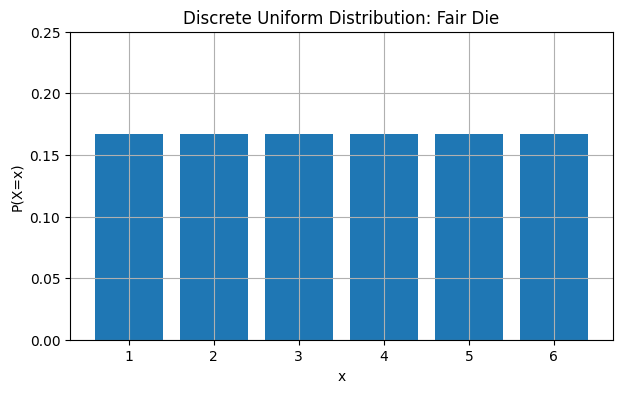

Mean of fair die = 3.5
Variance of fair die = 2.9167


In [12]:
a, b = 1, 6
x = np.arange(a, b + 1)
pmf_die = np.ones_like(x, dtype=float) / len(x)

plt.figure()
plt.bar(x, pmf_die)
plt.xlabel("x")
plt.ylabel("P(X=x)")
plt.title("Discrete Uniform Distribution: Fair Die")
plt.ylim(0, 0.25)
plt.show()

print(f"Mean of fair die = {(a+b)/2}")
print(f"Variance of fair die = {((b-a+1)**2 - 1)/12:.4f}")

### 3.5 Hypergeometric distribution

The hypergeometric distribution describes sampling without replacement.

Suppose an urn has $N$ balls, $M$ red balls, and $N-M$ green balls. We draw $K$ balls without replacement. If $X$ is the number of red balls drawn, then

$$
P(X=x)=\frac{\binom{M}{x}\binom{N-M}{K-x}}{\binom{N}{K}}.
$$

### Exercise 3.4: Quality-control sampling

A lot has $N=100$ parts. An unacceptable lot has at least $M=6$ defective parts. We inspect $K=36$ parts without replacement and accept the lot if no defective parts are found.

Compute the probability of accepting this unacceptable lot.

### Solution

In [13]:
N, M, K = 100, 6, 36
# scipy.stats.hypergeom uses parameters M=population size, n=success states, N=draws
prob_accept = stats.hypergeom.pmf(0, M=N, n=M, N=K)
print(f"P(no defective parts in sample) = {prob_accept:.5f}")

P(no defective parts in sample) = 0.06290


### 3.6 Negative binomial distribution

One common convention: $X$ is the number of trials needed to get $r$ successes. Then

$$
P(X=n)=\binom{n-1}{r-1}p^r(1-p)^{n-r},\qquad n=r,r+1,\ldots
$$

### Exercise 3.5: Survey problem

Jim goes door to door until he obtains $r=30$ completed surveys. At each house, the probability of completing a survey is $p=0.6$. What is the probability that the last required survey is completed at the $n=45$-th house?

### Solution

The 45-th house must be a success, and among the first 44 houses there must be exactly 29 successes.

In [14]:
r, p_survey, n_house = 30, 0.6, 45
prob_last_at_45 = comb(n_house - 1, r - 1) * (p_survey**r) * ((1 - p_survey)**(n_house - r))
print(f"P(last required survey at house 45) = {prob_last_at_45:.6f}")

# scipy's nbinom counts failures before r successes. If total trials = n, failures = n-r.
prob_scipy = stats.nbinom.pmf(n_house - r, r, p_survey)
print(f"Same probability using scipy.stats.nbinom = {prob_scipy:.6f}")

P(last required survey at house 45) = 0.054576
Same probability using scipy.stats.nbinom = 0.054576


## 4. Common continuous distributions

### 4.1 Uniform distribution

If $X\sim \operatorname{Uniform}(a,b)$, then

$$
f_X(x)=\frac{1}{b-a},\qquad a<x<b.
$$

The mean is $(a+b)/2$ and the variance is $(b-a)^2/12$.

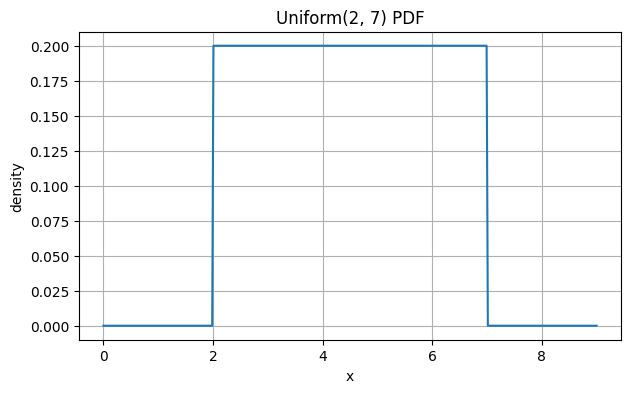

P(3 <= X <= 5) = 0.4000
Using scipy = 0.4000


In [15]:
a, b = 2, 7
x = np.linspace(0, 9, 400)
pdf_uniform = stats.uniform.pdf(x, loc=a, scale=b-a)

plt.figure()
plt.plot(x, pdf_uniform)
plt.xlabel("x")
plt.ylabel("density")
plt.title("Uniform(2, 7) PDF")
plt.show()

print(f"P(3 <= X <= 5) = {(5-3)/(b-a):.4f}")
print(f"Using scipy = {stats.uniform.cdf(5, loc=a, scale=b-a) - stats.uniform.cdf(3, loc=a, scale=b-a):.4f}")

### 4.2 Exponential distribution

If $X\sim \operatorname{Exponential}(\lambda)$ with rate $\lambda$, then

$$
f_X(x)=\lambda e^{-\lambda x},\qquad x\ge 0.
$$

It has mean $1/\lambda$ and variance $1/\lambda^2$.

### Exercise 4.1: Exponential tail and memoryless check

Let $X\sim \operatorname{Exponential}(\lambda=2)$. Compute

$$
P(X>1.5),\qquad P(X>2.5\mid X>1).
$$

### Solution

The tail probability is $P(X>x)=e^{-\lambda x}$. The memoryless property says

$$
P(X>s+t\mid X>s)=P(X>t).
$$

In [16]:
lam = 2.0
prob_tail = math.exp(-lam * 1.5)
prob_cond = math.exp(-lam * (2.5 - 1.0))

# Direct conditional probability check
prob_cond_direct = math.exp(-lam * 2.5) / math.exp(-lam * 1.0)

print(f"P(X > 1.5) = {prob_tail:.6f}")
print(f"P(X > 2.5 | X > 1) = {prob_cond:.6f}")
print(f"Direct calculation gives {prob_cond_direct:.6f}")

P(X > 1.5) = 0.049787
P(X > 2.5 | X > 1) = 0.049787
Direct calculation gives 0.049787


### 4.3 Gamma distribution

The gamma distribution is useful for waiting times. If arrivals follow a Poisson process with rate $\lambda$, then the waiting time until the $k$-th arrival has a gamma/Erlang distribution.

Using the shape-rate parameterization,

$$
f(x;\alpha,\lambda)=\frac{\lambda^\alpha}{\Gamma(\alpha)}x^{\alpha-1}e^{-\lambda x},\qquad x>0.
$$

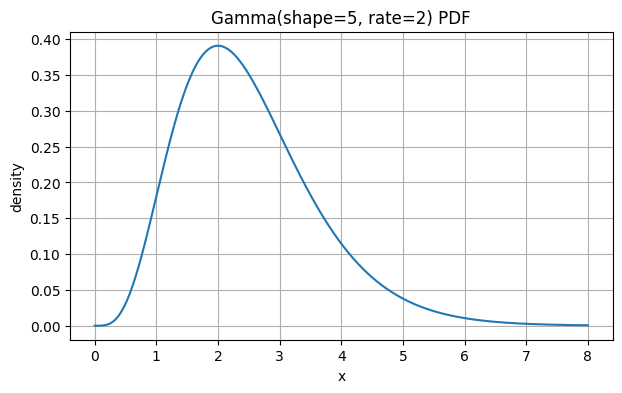

Mean = shape/rate = 2.500
Variance = shape/rate^2 = 1.250
P(X <= 3) = 0.7149


In [17]:
shape, rate = 5, 2.0
scale = 1 / rate
x = np.linspace(0, 8, 500)
pdf_gamma = stats.gamma.pdf(x, a=shape, scale=scale)

plt.figure()
plt.plot(x, pdf_gamma)
plt.xlabel("x")
plt.ylabel("density")
plt.title(r"Gamma(shape=5, rate=2) PDF")
plt.show()

print(f"Mean = shape/rate = {shape/rate:.3f}")
print(f"Variance = shape/rate^2 = {shape/rate**2:.3f}")
print(f"P(X <= 3) = {stats.gamma.cdf(3, a=shape, scale=scale):.4f}")

### 4.4 Normal distribution

If $X\sim N(\mu,\sigma^2)$, then

$$
f_X(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
$$

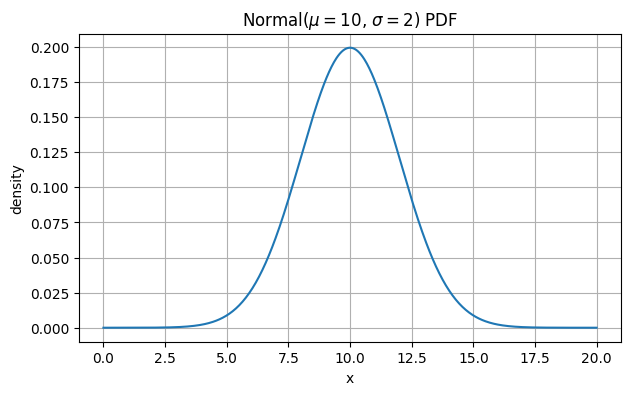

P(mu - 1 sigma <= X <= mu + 1 sigma) = 0.6827
P(mu - 2 sigma <= X <= mu + 2 sigma) = 0.9545
P(mu - 3 sigma <= X <= mu + 3 sigma) = 0.9973


In [18]:
mu, sigma = 10, 2
x = np.linspace(mu - 5*sigma, mu + 5*sigma, 600)
pdf_normal = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure()
plt.plot(x, pdf_normal)
plt.xlabel("x")
plt.ylabel("density")
plt.title(r"Normal($\mu=10$, $\sigma=2$) PDF")
plt.show()

for c in [1, 2, 3]:
    prob = stats.norm.cdf(mu + c*sigma, loc=mu, scale=sigma) - stats.norm.cdf(mu - c*sigma, loc=mu, scale=sigma)
    print(f"P(mu - {c} sigma <= X <= mu + {c} sigma) = {prob:.4f}")

### 4.5 Beta distribution

The beta distribution is supported on $(0,1)$ and is often used to model random proportions:

$$
f(x;\alpha,\beta)=\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}x^{\alpha-1}(1-x)^{\beta-1},\qquad 0<x<1.
$$

The mean and variance are

$$
E[X]=\frac{\alpha}{\alpha+\beta},
\qquad
\operatorname{Var}(X)=\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}.
$$

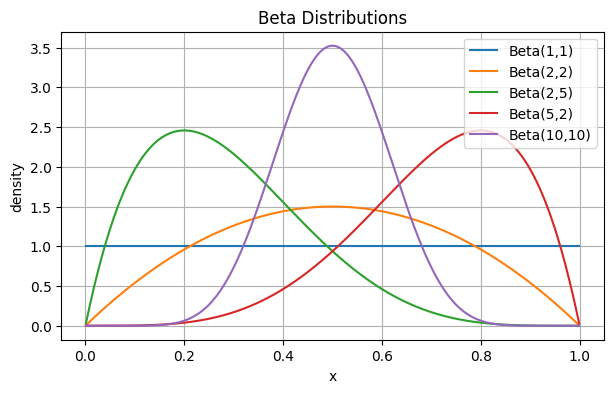

For Beta(2,5), mean = 0.2857, variance = 0.0255


In [19]:
x = np.linspace(0.001, 0.999, 500)
params = [(1, 1), (2, 2), (2, 5), (5, 2), (10, 10)]

plt.figure()
for alpha, beta in params:
    plt.plot(x, stats.beta.pdf(x, alpha, beta), label=f"Beta({alpha},{beta})")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Beta Distributions")
plt.legend()
plt.show()

alpha, beta = 2, 5
mean_beta = alpha / (alpha + beta)
var_beta = alpha * beta / ((alpha + beta)**2 * (alpha + beta + 1))
print(f"For Beta({alpha},{beta}), mean = {mean_beta:.4f}, variance = {var_beta:.4f}")

### 4.6 Lognormal distribution

If $Y=\log X\sim N(\mu,\sigma^2)$, then $X$ is lognormal. The PDF is

$$
f_X(x)=\frac{1}{x\sigma\sqrt{2\pi}}\exp\left[-\frac{(\log x-\mu)^2}{2\sigma^2}\right],\qquad x>0.
$$

The lognormal is often right-skewed and is useful for modeling positive quantities such as income, lifetimes, and sizes.

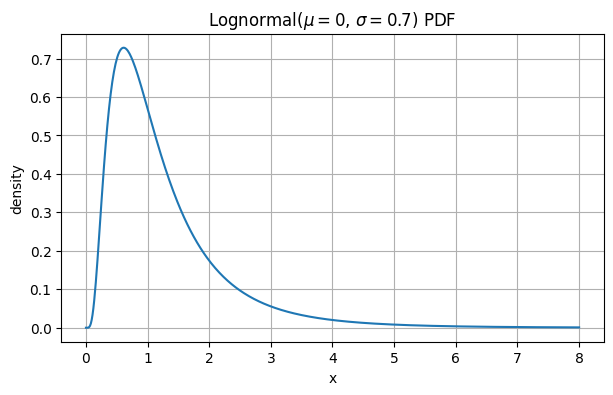

Mean = 1.2776
Variance = 1.0321


In [20]:
mu, sigma = 0, 0.7
x = np.linspace(0.001, 8, 600)
pdf_lognorm = stats.lognorm.pdf(x, s=sigma, scale=math.exp(mu))

plt.figure()
plt.plot(x, pdf_lognorm)
plt.xlabel("x")
plt.ylabel("density")
plt.title(r"Lognormal($\mu=0$, $\sigma=0.7$) PDF")
plt.show()

mean_lognorm = math.exp(mu + sigma**2 / 2)
var_lognorm = (math.exp(sigma**2) - 1) * math.exp(2*mu + sigma**2)
print(f"Mean = {mean_lognorm:.4f}")
print(f"Variance = {var_lognorm:.4f}")

### 4.7 Laplace and Logistic distributions

The Laplace distribution, also called the double exponential distribution, is more sharply peaked than the normal and has heavier tails.

The logistic distribution has CDF

$$
F(x)=\frac{1}{1+e^{-(x-\mu)/s}},
$$

and appears naturally in logistic regression.

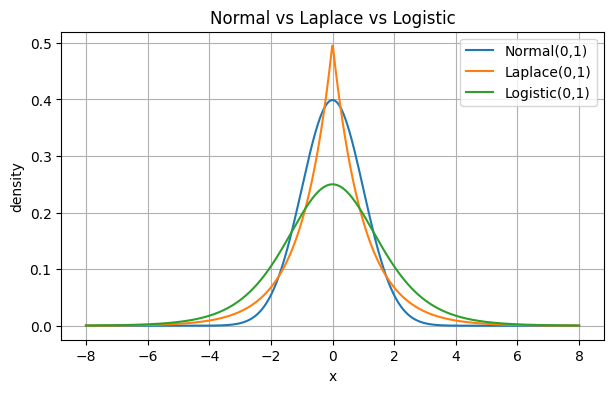

In [21]:
x = np.linspace(-8, 8, 800)

laplace_pdf = stats.laplace.pdf(x, loc=0, scale=1)
logistic_pdf = stats.logistic.pdf(x, loc=0, scale=1)
normal_pdf = stats.norm.pdf(x, loc=0, scale=1)

plt.figure()
plt.plot(x, normal_pdf, label="Normal(0,1)")
plt.plot(x, laplace_pdf, label="Laplace(0,1)")
plt.plot(x, logistic_pdf, label="Logistic(0,1)")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Normal vs Laplace vs Logistic")
plt.legend()
plt.show()

## 5. Exponential family

A distribution belongs to an exponential family if its PMF/PDF can be written as

$$
p(y;\eta)=h(y)\exp\{\eta^T T(y)-A(\eta)\}.
$$

Important components:

- $\eta$: natural parameter.
- $T(y)$: sufficient statistic.
- $A(\eta)$: log-partition function.
- $h(y)$: base measure.

For one-parameter exponential families,

$$
A'(\eta)=E_\eta[T(Y)], \qquad A''(\eta)=\operatorname{Var}_\eta(T(Y)).
$$

### Exercise 5.1: Bernoulli exponential family

For $Y\sim \operatorname{Bernoulli}(p)$,

$$
P(Y=y)=p^y(1-p)^{1-y},\qquad y\in\{0,1\}.
$$

Write this in exponential-family form and verify that $A'(\eta)$ gives the mean.

### Solution

Let

$$
\eta=\log\frac{p}{1-p}.
$$

Then

$$
p=\frac{e^\eta}{1+e^\eta}.
$$

The Bernoulli PMF becomes

$$
P(Y=y)=\exp\{\eta y-\log(1+e^\eta)\}.
$$

Thus $T(y)=y$, $h(y)=1$, and

$$
A(\eta)=\log(1+e^\eta).
$$

Then

$$
A'(\eta)=\frac{e^\eta}{1+e^\eta}=p=E[Y].
$$

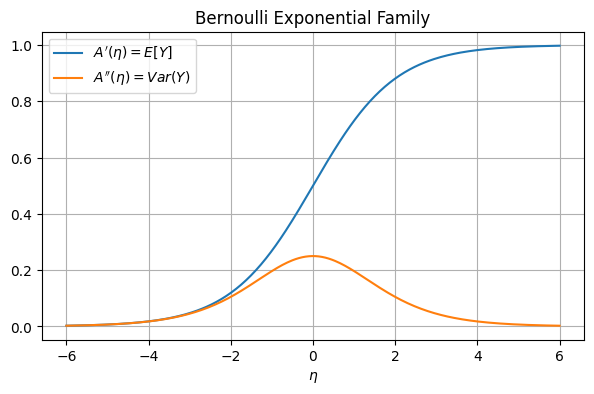

eta = 0.7
p = exp(eta)/(1+exp(eta)) = 0.6682
A'(eta) = 0.6682
A''(eta) = 0.2217
p(1-p) = 0.2217


In [22]:
def A_bernoulli(eta):
    return np.log1p(np.exp(eta))

def A1_bernoulli(eta):
    return np.exp(eta) / (1 + np.exp(eta))

def A2_bernoulli(eta):
    p = A1_bernoulli(eta)
    return p * (1 - p)

eta_grid = np.linspace(-6, 6, 300)

plt.figure()
plt.plot(eta_grid, A1_bernoulli(eta_grid), label=r"$A'(\eta)=E[Y]$")
plt.plot(eta_grid, A2_bernoulli(eta_grid), label=r"$A''(\eta)=Var(Y)$")
plt.xlabel(r"$\eta$")
plt.title("Bernoulli Exponential Family")
plt.legend()
plt.show()

eta = 0.7
p_from_eta = A1_bernoulli(eta)
print(f"eta = {eta}")
print(f"p = exp(eta)/(1+exp(eta)) = {p_from_eta:.4f}")
print(f"A'(eta) = {A1_bernoulli(eta):.4f}")
print(f"A''(eta) = {A2_bernoulli(eta):.4f}")
print(f"p(1-p) = {p_from_eta*(1-p_from_eta):.4f}")

### Exercise 5.2: Poisson exponential family

For $Y\sim \operatorname{Poisson}(\lambda)$,

$$
P(Y=y)=\frac{e^{-\lambda}\lambda^y}{y!}.
$$

Let $\eta=\log\lambda$. Show that this is an exponential family and verify the mean and variance.

### Solution

Since $\lambda=e^\eta$,

$$
P(Y=y)=\frac{1}{y!}\exp\{\eta y-e^\eta\}.
$$

Thus

$$
T(y)=y,\qquad h(y)=\frac{1}{y!},\qquad A(\eta)=e^\eta.
$$

Therefore

$$
A'(\eta)=e^\eta=\lambda,
\qquad
A''(\eta)=e^\eta=\lambda.
$$

This matches the fact that a Poisson random variable has mean and variance both equal to $\lambda$.

In [23]:
def A_poisson(eta):
    return np.exp(eta)

def A1_poisson(eta):
    return np.exp(eta)

def A2_poisson(eta):
    return np.exp(eta)

eta = math.log(4)
print(f"eta = log(4) = {eta:.4f}")
print(f"A'(eta) = {A1_poisson(eta):.4f}")
print(f"A''(eta) = {A2_poisson(eta):.4f}")
print("Both equal lambda = 4.")

eta = log(4) = 1.3863
A'(eta) = 4.0000
A''(eta) = 4.0000
Both equal lambda = 4.


## 6. Location-scale families

If $X$ has CDF $F$ and PDF $f$, and

$$
Y=\mu+\sigma X,\qquad \sigma>0,
$$

then

$$
F_Y(y)=F\left(\frac{y-\mu}{\sigma}\right),
\qquad
f_Y(y)=\frac{1}{\sigma}f\left(\frac{y-\mu}{\sigma}\right).
$$

Normal, logistic, Laplace, Cauchy, and many uniform distributions are location-scale families.

### Exercise 6.1: Verify the location-scale formula by simulation

Let $X\sim N(0,1)$ and define $Y=\mu+\sigma X$ with $\mu=5$ and $\sigma=2$.

1. Simulate $Y$.
2. Compare the histogram with the theoretical $N(5,4)$ density.
3. Estimate the mean and variance.

### Solution

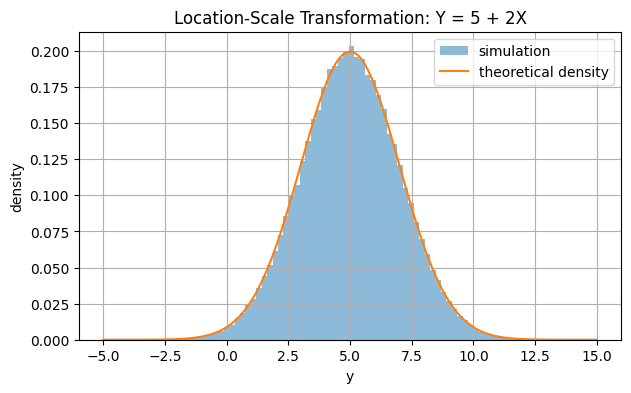

Simulated mean = 5.0152; theoretical mean = 5
Simulated variance = 3.9859; theoretical variance = 4


In [24]:
mu, sigma = 5, 2
Nsim = 200_000
X = rng.normal(0, 1, size=Nsim)
Y = mu + sigma * X

x_grid = np.linspace(mu - 5*sigma, mu + 5*sigma, 600)

plt.figure()
plt.hist(Y, bins=80, density=True, alpha=0.5, label="simulation")
plt.plot(x_grid, stats.norm.pdf(x_grid, loc=mu, scale=sigma), label="theoretical density")
plt.xlabel("y")
plt.ylabel("density")
plt.title("Location-Scale Transformation: Y = 5 + 2X")
plt.legend()
plt.show()

print(f"Simulated mean = {Y.mean():.4f}; theoretical mean = {mu}")
print(f"Simulated variance = {Y.var():.4f}; theoretical variance = {sigma**2}")

## 7. Summary table of selected distributions

The following table records common stories, supports, means, and variances. This is a useful reference when selecting models.

In [25]:
distribution_table = pd.DataFrame([
    ["Bernoulli(p)", "single success/failure", "{0,1}", "p", "p(1-p)"],
    ["Binomial(n,p)", "number of successes in n trials", "0,...,n", "np", "np(1-p)"],
    ["Geometric(p)", "trials until first success", "1,2,...", "1/p", "(1-p)/p^2"],
    ["Poisson(lambda)", "arrivals in fixed time", "0,1,2,...", "lambda", "lambda"],
    ["Discrete Uniform(a,b)", "equally likely integers", "a,...,b", "(a+b)/2", "((b-a+1)^2-1)/12"],
    ["Hypergeometric(N,M,K)", "successes without replacement", "finite", "K M/N", "finite-population variance"],
    ["Negative Binomial(r,p)", "trials until r successes", "r,r+1,...", "r/p", "r(1-p)/p^2"],
    ["Uniform(a,b)", "random point in interval", "(a,b)", "(a+b)/2", "(b-a)^2/12"],
    ["Exponential(lambda)", "waiting time to first arrival", "[0, infinity)", "1/lambda", "1/lambda^2"],
    ["Gamma(alpha, rate lambda)", "waiting time to alpha-th arrival", "[0, infinity)", "alpha/lambda", "alpha/lambda^2"],
    ["Normal(mu, sigma^2)", "measurement with symmetric noise", "R", "mu", "sigma^2"],
    ["Beta(alpha,beta)", "random proportion", "(0,1)", "alpha/(alpha+beta)", "alpha beta / [(alpha+beta)^2(alpha+beta+1)]"],
    ["Lognormal(mu,sigma^2)", "exp of normal", "(0, infinity)", "exp(mu+sigma^2/2)", "right-skewed"],
    ["Laplace(mu,b)", "double exponential", "R", "mu", "2b^2"],
    ["Logistic(mu,s)", "logistic-regression latent error", "R", "mu", "pi^2 s^2/3"],
], columns=["Distribution", "Story", "Support", "Mean", "Variance"])

distribution_table

,Distribution,Story,Support,Mean,Variance
0,Bernoulli(p),single success/failure,"{0,1}",p,p(1-p)
1,"Binomial(n,p)",number of successes in n trials,"0,...,n",np,np(1-p)
2,Geometric(p),trials until first success,"1,2,...",1/p,(1-p)/p^2
3,Poisson(lambda),arrivals in fixed time,"0,1,2,...",lambda,lambda
4,"Discrete Uniform(a,b)",equally likely integers,"a,...,b",(a+b)/2,((b-a+1)^2-1)/12
5,"Hypergeometric(N,M,K)",successes without replacement,finite,K M/N,finite-population variance
6,"Negative Binomial(r,p)",trials until r successes,"r,r+1,...",r/p,r(1-p)/p^2
7,"Uniform(a,b)",random point in interval,"(a,b)",(a+b)/2,(b-a)^2/12
8,Exponential(lambda),waiting time to first arrival,"[0, infinity)",1/lambda,1/lambda^2
9,"Gamma(alpha, rate lambda)",waiting time to alpha-th arrival,"[0, infinity)",alpha/lambda,alpha/lambda^2


## 8. Practice problems with complete solutions

### Practice Problem 1: PMF and CDF from a random variable

Two fair dice are rolled. Let $X=|D_1-D_2|$.

1. Find the PMF of $X$.
2. Find the CDF of $X$.
3. Compute $P(X\ge 3)$.

### Solution

We enumerate the 36 ordered outcomes and count the values of $|D_1-D_2|$.

In [26]:
outcomes = [(i, j) for i in range(1, 7) for j in range(1, 7)]
X_diff = np.array([abs(i - j) for i, j in outcomes])
pmf_diff = pd.Series(X_diff).value_counts(normalize=True).sort_index()
cdf_diff = pmf_diff.cumsum()

result_diff = pd.DataFrame({
    "x": pmf_diff.index,
    "P(X=x)": pmf_diff.values,
    "F(x)=P(X<=x)": cdf_diff.values
})

display(result_diff)
print(f"P(X >= 3) = {pmf_diff.loc[pmf_diff.index >= 3].sum():.4f}")

,x,P(X=x),F(x)=P(X<=x)
0,0,0.166667,0.166667
1,1,0.277778,0.444444
2,2,0.222222,0.666667
3,3,0.166667,0.833333
4,4,0.111111,0.944444
5,5,0.055556,1.000000


P(X >= 3) = 0.3333


### Practice Problem 2: Find a normalizing constant

Find $c$ such that

$$
f(x)=c\cos x,\qquad -\frac{\pi}{2}<x<\frac{\pi}{2}
$$

is a valid PDF.

### Solution

We require

$$
\int_{-\pi/2}^{\pi/2}c\cos x\,dx=1.
$$

Since

$$
\int_{-\pi/2}^{\pi/2}\cos x\,dx=2,
$$

we get $2c=1$, so

$$
c=\frac12.
$$

In [27]:
c = 1/2
x = np.linspace(-np.pi/2, np.pi/2, 500)
pdf = c * np.cos(x)
area = np.trapz(pdf, x)

plt.figure()
plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"PDF $f(x)=\frac12\cos x$ on $(-\pi/2,\pi/2)$")
plt.show()

print(f"Numerical integral = {area:.6f}")

/tmp/ipykernel_17716/3297544836.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, x)


ValueError: 
f(x)=\frac12\cos x
          ^
ParseSyntaxException: Expected \frac{num}{den}, found '12'  (at char 10), (line:1, col:11)

<Figure size 700x400 with 1 Axes>

Numerical integral = 0.999997


### Practice Problem 3: A mixed distribution

Let $T\sim \operatorname{Exponential}(\theta=1.5)$ in the scale parameterization, so

$$
f_T(t)=\frac{1}{1.5}e^{-t/1.5},\qquad t>0.
$$

Define

$$
V=\begin{cases}
5, & T<3,\\
2T, & T\ge 3.
\end{cases}
$$

1. Find $P(V=5)$.
2. Find the continuous density of $V$ for $v\ge 6$.
3. Verify by simulation.

### Solution

The point mass is

$$
P(V=5)=P(T<3)=1-e^{-3/1.5}=1-e^{-2}.
$$

For $v\ge 6$, $V=2T$, so $T=v/2$ and $dt/dv=1/2$. Thus

$$
f_V(v)=f_T(v/2)\frac12=\frac{1}{3}e^{-v/3},\qquad v\ge 6.
$$

P(V=5) = 1 - exp(-2) = 0.864665
Simulated mass near V=5 exactly = 0.864687


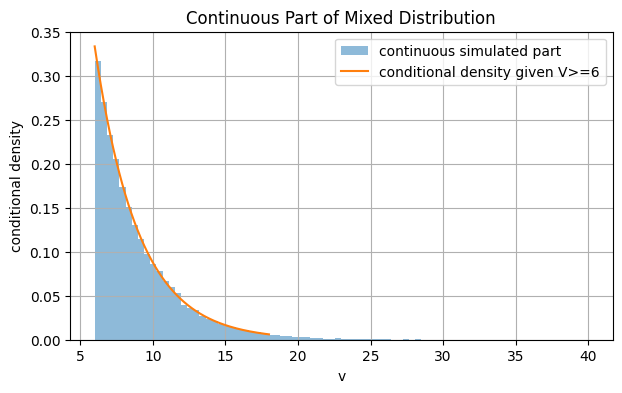

In [28]:
theta = 1.5
mass_at_5 = 1 - math.exp(-3/theta)
print(f"P(V=5) = 1 - exp(-2) = {mass_at_5:.6f}")

# Simulate
T = rng.exponential(scale=theta, size=300_000)
V = np.where(T < 3, 5, 2*T)
print(f"Simulated mass near V=5 exactly = {np.mean(V == 5):.6f}")

v_grid = np.linspace(6, 18, 400)
density_v = (1/3) * np.exp(-v_grid/3)

plt.figure()
plt.hist(V[V > 5], bins=80, density=True, alpha=0.5, label="continuous simulated part")
plt.plot(v_grid, density_v / math.exp(-2), label="conditional density given V>=6")
plt.xlabel("v")
plt.ylabel("conditional density")
plt.title("Continuous Part of Mixed Distribution")
plt.legend()
plt.show()

### Practice Problem 4: Beta distribution as a model for proportions

Suppose $P\sim \operatorname{Beta}(4,6)$.

1. Compute $E[P]$ and $\operatorname{Var}(P)$.
2. Compute $P(0.3<P<0.7)$.
3. Verify by simulation.

### Solution

In [29]:
alpha, beta = 4, 6
mean = alpha / (alpha + beta)
var = alpha * beta / ((alpha + beta)**2 * (alpha + beta + 1))
prob_interval = stats.beta.cdf(0.7, alpha, beta) - stats.beta.cdf(0.3, alpha, beta)

sim = rng.beta(alpha, beta, size=300_000)
sim_mean = sim.mean()
sim_var = sim.var()
sim_prob = np.mean((sim > 0.3) & (sim < 0.7))

print(f"Theoretical E[P] = {mean:.5f}")
print(f"Simulated E[P]   = {sim_mean:.5f}")
print(f"Theoretical Var(P) = {var:.5f}")
print(f"Simulated Var(P)   = {sim_var:.5f}")
print(f"Theoretical P(0.3<P<0.7) = {prob_interval:.5f}")
print(f"Simulated P(0.3<P<0.7)   = {sim_prob:.5f}")

Theoretical E[P] = 0.40000
Simulated E[P]   = 0.40014
Theoretical Var(P) = 0.02182
Simulated Var(P)   = 0.02194
Theoretical P(0.3<P<0.7) = 0.70436
Simulated P(0.3<P<0.7)   = 0.70385


### Practice Problem 5: Location-scale transformation

Let $X$ have logistic distribution with location $0$ and scale $1$. Define

$$
Y=3+2X.
$$

Find the CDF and PDF of $Y$.

### Solution

For a location-scale transformation,

$$
F_Y(y)=F_X\left(\frac{y-3}{2}\right),
$$

and

$$
f_Y(y)=\frac12 f_X\left(\frac{y-3}{2}\right).
$$

We verify this numerically below.

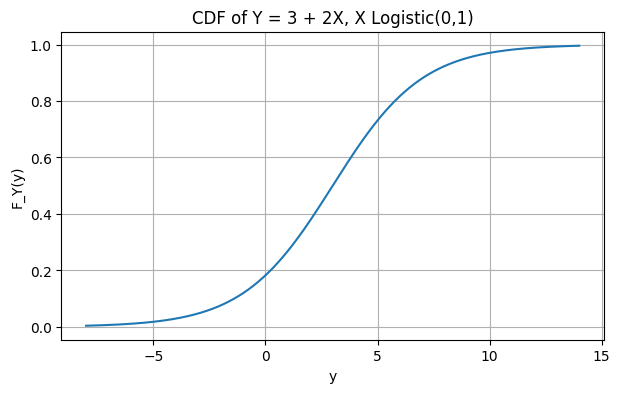

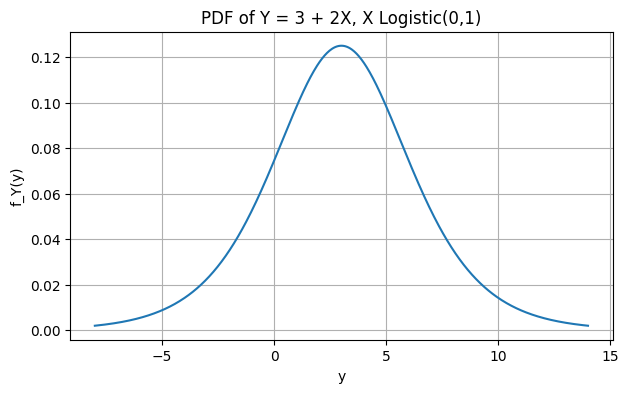

Mean of Y = 3 + 2*0 = 3
Variance of Y = 2^2 * pi^2/3 = 13.1595


In [30]:
y = np.linspace(-8, 14, 600)
FY = stats.logistic.cdf((y - 3) / 2)
fY = 0.5 * stats.logistic.pdf((y - 3) / 2)

plt.figure()
plt.plot(y, FY)
plt.xlabel("y")
plt.ylabel("F_Y(y)")
plt.title("CDF of Y = 3 + 2X, X Logistic(0,1)")
plt.show()

plt.figure()
plt.plot(y, fY)
plt.xlabel("y")
plt.ylabel("f_Y(y)")
plt.title("PDF of Y = 3 + 2X, X Logistic(0,1)")
plt.show()

print(f"Mean of Y = 3 + 2*0 = 3")
print(f"Variance of Y = 2^2 * pi^2/3 = {4 * math.pi**2 / 3:.4f}")

## 9. Lab checklist

After completing this lab, you should be able to:

- Build a random variable from a sample space.
- Compute and plot PMFs and CDFs for discrete random variables.
- Use PDFs and CDFs to compute probabilities for continuous random variables.
- Simulate from common probability distributions.
- Recognize distributional stories for Bernoulli, Binomial, Geometric, Poisson, Hypergeometric, Negative Binomial, Uniform, Exponential, Gamma, Normal, Beta, Lognormal, Laplace, and Logistic distributions.
- Interpret the exponential-family form and verify $A'(\eta)$ and $A''(\eta)$ for Bernoulli and Poisson examples.
- Apply the location-scale transformation formula.